# NHL Cap Hit: expected share of salary cap

Build an **expected share of salary cap** (`CapHit_pct`) for NHL skaters, then use residuals (actual minus expected) as a reevaluation / comps signal. Not a market verdict.

**Stack.** Performance + role proxies + team + contract + HockeyStats WAR + defense / physical counts + a small NHL Edge block. CatBoost. SHAP for drivers.

**Setup**
- Train `23/24` + `24/25` → review `25/26`
- Skaters with at least 10 games; goalies out of scope
- CapHit = full contractual hit (not mid-season retain splits)
- Residual = actual share of salary cap minus expected share

**Sequence**
1. Load + fit + holdout metrics
2. League residuals
3. Drivers (importance, SHAP, length vs everything else)
4. Entry-level: next-contract potential
5. Summary


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from viz_labels import lab, labs

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

ROOT = Path.cwd()
DATA = ROOT / "NHL Skater Cap Hit.csv"
PP = 100  # CapHit_pct fraction -> percentage points of salary-cap share


## 1. Load, fit, and holdout metrics

Modeling table (`NHL Skater Cap Hit.csv`). Target is share of salary cap. Train on `23/24`–`24/25`, review `25/26`.


In [4]:
df = pd.read_csv(DATA)

TARGET = "CapHit_pct"
META_COLS = ["playerId", "Player", "Season", "Team", "CapHit", "CapHit_pct"]

FEATURE_COLS = [
    "Season_id", "Pos_group", "S/C", "Age", "heightInInches", "weightInPounds", "GP",
    "TOI/GP", "Depth_TOI_rank", "PP TOI", "PK TOI",
    "Is_ELC", "ContractLength", "YearsRemaining",
    "WAR_per_GP", "EVO WAR", "EVD WAR", "PP WAR", "PK WAR",
    "pointsPerGame", "ixG", "shots",
    "xGF%", "OZ Start%", "xG_diff",
    "Hits", "HitsT", "BkS", "TkA", "GvA", "penaltyMinutes", "DZ Start%",
    "Team_pointPct", "Team_GF_pct", "Team_PP%", "Team_PK%",
    "nhl_edge_skatingSpeedMax_mph", "nhl_edge_burstsOver20", "nhl_edge_topShotSpeed_mph",
    "nhl_edge_totalDistanceSkated_mph", "nhl_edge_distanceMaxGame_mph",
    "nhl_edge_zoneTime_offensiveZonePctg",
]
CAT_FEATURES = ["Pos_group", "S/C"]

assert TARGET in df.columns
assert set(FEATURE_COLS).issubset(df.columns)

train = df[df["Season"].isin(["23-24", "24-25"])].copy()
test = df[df["Season"] == "25-26"].copy()

X_train = train[FEATURE_COLS].copy()
y_train = train[TARGET].copy()
X_test = test[FEATURE_COLS].copy()
y_test = test[TARGET].copy()

for c in CAT_FEATURES:
    X_train[c] = X_train[c].astype(str).fillna("NA")
    X_test[c] = X_test[c].astype(str).fillna("NA")

train_pool = Pool(X_train, y_train, cat_features=CAT_FEATURES)
test_pool = Pool(X_test, y_test, cat_features=CAT_FEATURES)

model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=800,
    learning_rate=0.05,
    depth=6,
    random_seed=666,
    early_stopping_rounds=50,
    verbose=100,
)
model.fit(train_pool, eval_set=test_pool, use_best_model=True)

pred_test = model.predict(X_test)
rmse = mean_squared_error(y_test, pred_test) ** 0.5
mae = mean_absolute_error(y_test, pred_test)
r2 = r2_score(y_test, pred_test)

print(f"train {X_train.shape} | test {X_test.shape} | features {len(FEATURE_COLS)}")
print(f"Best iteration: {model.get_best_iteration()}")
print(f"RMSE {rmse:.5f} | MAE {mae:.5f} | R2 {r2:.4f}")

implied_cap = (test["CapHit"] / test["CapHit_pct"]).replace([np.inf, -np.inf], np.nan)
cap_proxy = implied_cap.median()
resid_M = (y_test - pred_test) * implied_cap
print(f"MAE ~ ${mae * cap_proxy:.3f}M at median salary cap")
print(
    f"Holdout with $ residual: {int(resid_M.notna().sum())} | "
    f"share inside +/- $1M: {(resid_M.abs() <= 1).mean():.0%}"
)


0:	learn: 0.0308629	test: 0.0287618	best: 0.0287618 (0)	total: 229ms	remaining: 3m 2s
100:	learn: 0.0105855	test: 0.0114582	best: 0.0114582 (100)	total: 9.92s	remaining: 1m 8s
200:	learn: 0.0085349	test: 0.0112501	best: 0.0112436 (196)	total: 18.9s	remaining: 56.4s
300:	learn: 0.0072585	test: 0.0112481	best: 0.0112356 (274)	total: 28.2s	remaining: 46.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.01123562027
bestIteration = 274

Shrink model to first 275 iterations.
train (1532, 42) | test (778, 42) | features 42
Best iteration: 274
RMSE 0.01124 | MAE 0.00801 | R2 0.8575
MAE ~ $0.765M at median salary cap
Holdout with $ residual: 778 | share inside +/- $1M: 71%


### Takeaways

The holdout is stable enough to use residuals as a signal: expected share of salary cap versus what the player actually carries. On this run, average miss is about **$0.77M**, with most players inside about **$1M** of expected pay and **R² around 0.86**. Residuals flag deals worth a second look for comps and negotiation prep. They are not a verdict that a club overpaid or underpaid.


## 2. League residuals (25/26)

Who sits furthest under or over expected cap share in this sample.


In [5]:
REVIEW_EXTRA = [
    "Pos_group", "Age", "Is_ELC", "ContractLength", "YearsRemaining",
    "GP", "TOI/GP", "pointsPerGame", "shots",
]
review = test[META_COLS + REVIEW_EXTRA].copy()
review["CapHit_pct_pred"] = pred_test
review["residual_pct"] = review["CapHit_pct"] - review["CapHit_pct_pred"]
implied_cap = (review["CapHit"] / review["CapHit_pct"]).replace([np.inf, -np.inf], np.nan)
review["residual_M"] = review["residual_pct"] * implied_cap
review["pred_M"] = review["CapHit_pct_pred"] * implied_cap
review["actual_pct"] = review["CapHit_pct"]
review["pred_pct"] = review["CapHit_pct_pred"]
review["residual_pp"] = review["residual_pct"]
review = review.sort_values("residual_pct")

CORE_COLS = ["Player", "Team", "Age", "Pos_group", "actual_pct", "pred_pct", "residual_pp"]
EARLY_COLS = CORE_COLS + ["ContractLength", "YearsRemaining", "Is_ELC"]
ELC_PERF_COLS = CORE_COLS + ["GP", "pointsPerGame", "TOI/GP", "shots"]

RENAME = {
    "actual_pct": "Actual cap share (%)",
    "pred_pct": "Expected cap share (%)",
    "residual_pp": "Residual (pp)",
    "pred_pct_elc": "Expected % (as ELC)",
    "pred_pct_if_not_ELC": "Expected % if not ELC",
    "next_deal": "Signed next deal",
    "next_aav_m": "Next AAV / CapHit ($M)",
    "next_length": "Next length (years)",
    "length_pp": "Length effect (pp)",
    "rest_no_length_pp": "Everything else (pp)",
}

PCT_COLS = {
    "actual_pct", "pred_pct", "residual_pp", "CapHit_pct", "CapHit_pct_pred",
    "residual_pct", "pred_pct_elc", "pred_pct_if_not_ELC",
}


def show_players(frame, cols):
    out = frame[cols].copy()
    for c in out.columns.intersection(PCT_COLS):
        out[c] = (out[c] * PP).round(2)
    display(out.rename(columns=lambda c: RENAME.get(c, lab(c))))


Most under vs model (top 10)


,Player,Team,Age,Position,Actual cap share (%),Expected cap share (%),Residual (pp),Contract length (years),Years left on contract,Entry-level contract
1632,Ryan Nugent-Hopkins,EDM,32,C,5.37,9.10,-3.73,8,3,0
1582,Darren Raddysh,TBL,29,D,1.02,4.74,-3.72,2,0,0
1639,Brad Marchand,FLA,37,W,5.50,8.72,-3.22,6,5,0
1777,Brent Burns,COL,40,D,1.05,4.24,-3.19,1,0,0
1627,Jackson LaCombe,ANA,24,D,0.97,4.05,-3.08,2,0,0
1992,Zach Whitecloud,CGY,28,D,2.88,5.89,-3.01,6,2,0
2307,Dmitry Kulikov,FLA,34,D,1.20,4.17,-2.97,4,2,0
1893,Freddy Gaudreau,SEA,32,C,2.20,5.04,-2.84,5,2,0
1636,Josh Morrissey,WPG,30,D,6.54,9.34,-2.79,8,2,0
1550,Matt Boldy,MIN,24,W,7.33,10.09,-2.76,7,4,0



Most over vs model (top 10)


,Player,Team,Age,Position,Actual cap share (%),Expected cap share (%),Residual (pp),Contract length (years),Years left on contract,Entry-level contract
1645,Auston Matthews,TOR,28,C,13.87,6.84,7.03,4,2,0
1540,Leon Draisaitl,EDM,29,C,14.66,11.07,3.59,8,7,0
1715,Bowen Byram,BUF,24,D,6.54,3.02,3.52,2,1,0
1568,Sidney Crosby,PIT,38,C,9.11,5.69,3.42,2,1,0
1557,Mitch Marner,VGK,28,W,12.57,9.42,3.15,8,7,0
1600,Brock Nelson,COL,33,C,7.85,4.73,3.12,3,2,0
1657,Elias Pettersson,VAN,26,C,12.15,9.08,3.06,8,6,0
2042,Dylan Samberg,WPG,26,D,6.02,2.96,3.06,3,2,0
2184,Jordan Greenway,BUF,28,W,4.19,1.21,2.98,2,1,0
1717,Mikael Granlund,ANA,33,C,7.33,4.50,2.83,3,2,0


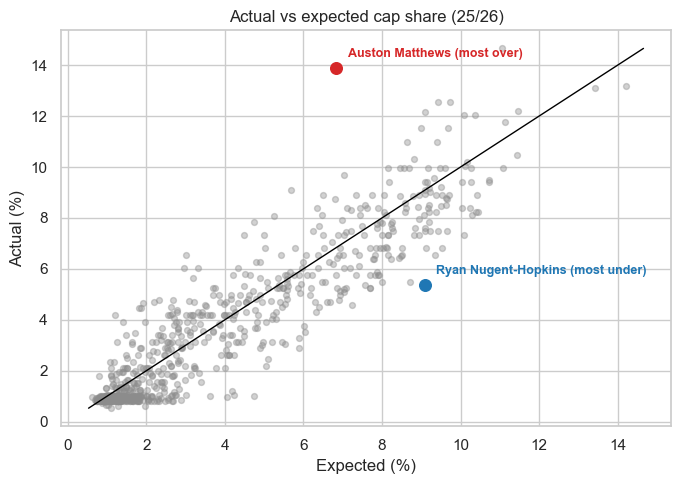

Leaders: under = Ryan Nugent-Hopkins (-3.73 pp); over = Auston Matthews (+7.03 pp)


In [8]:
print("Most under vs model (top 10)")
show_players(review.head(10), EARLY_COLS)

print("\nMost over vs model (top 10)")
show_players(review.tail(10).iloc[::-1], EARLY_COLS)

under = review.iloc[0]
over = review.iloc[-1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(review["pred_pct"] * PP, review["actual_pct"] * PP, alpha=0.4, s=18, color="0.55")
lo = min(review["pred_pct"].min(), review["actual_pct"].min()) * PP
hi = max(review["pred_pct"].max(), review["actual_pct"].max()) * PP
ax.plot([lo, hi], [lo, hi], color="black", lw=1)

for row, color, tag in [(under, "#1f77b4", "most under"), (over, "#d62728", "most over")]:
    x, y = float(row["pred_pct"]) * PP, float(row["actual_pct"]) * PP
    ax.scatter([x], [y], s=70, color=color, zorder=5)
    ax.annotate(
        f"{row['Player']} ({tag})",
        (x, y),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=9,
        fontweight="bold",
        color=color,
    )

ax.set_xlabel("Expected (%)")
ax.set_ylabel("Actual (%)")
ax.set_title("Actual vs expected cap share (25/26)")
plt.tight_layout()
plt.show()

print(
    f"Leaders: under = {under['Player']} ({under['residual_pp'] * PP:+.2f} pp); "
    f"over = {over['Player']} ({over['residual_pp'] * PP:+.2f} pp)"
)


### Takeaways

The league map is noisy on purpose: short expensive deals, veterans on cheap one-year terms, and other atypical structures show large residuals. On this run the farthest under is **Ryan Nugent-Hopkins** and the farthest over is **Auston Matthews**. That scale shows the model can flag outliers, not only calm middle-of-the-market deals.


## 3. What drives expected cap share

Contract length is the strongest single lever. The rest of the profile (performance, role, ELC / years left) still moves expected pay around that anchor.

**Reading the units.** The model predicts `CapHit_pct` (share of the salary cap). Charts below use **percentage points (pp)** of that share. At a **95M** cap, **1 pp ≈ 0.95M**. Example: a residual of about **-2.5 pp** is roughly **-2.4M** versus expected pay. Same idea for SHAP: a +1 pp length effect means length alone lifted expected share by about $0.95M at that cap.


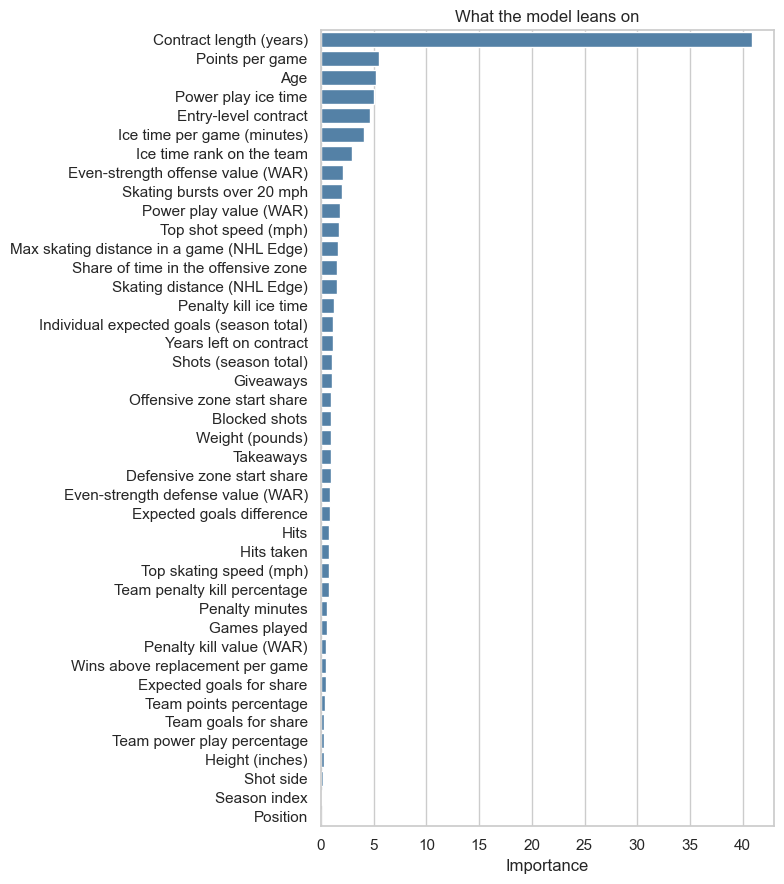

In [11]:
imp = (
    pd.DataFrame({"feature": FEATURE_COLS, "importance": model.get_feature_importance(train_pool)})
    .sort_values("importance", ascending=False)
)
fig, ax = plt.subplots(figsize=(8, 9))
sns.barplot(
    data=imp.assign(label=labs(imp["feature"].tolist())),
    y="label",
    x="importance",
    ax=ax,
    color="steelblue",
)
ax.set_xlabel("Importance")
ax.set_ylabel("")
ax.set_title("What the model leans on")
plt.tight_layout()
plt.show()


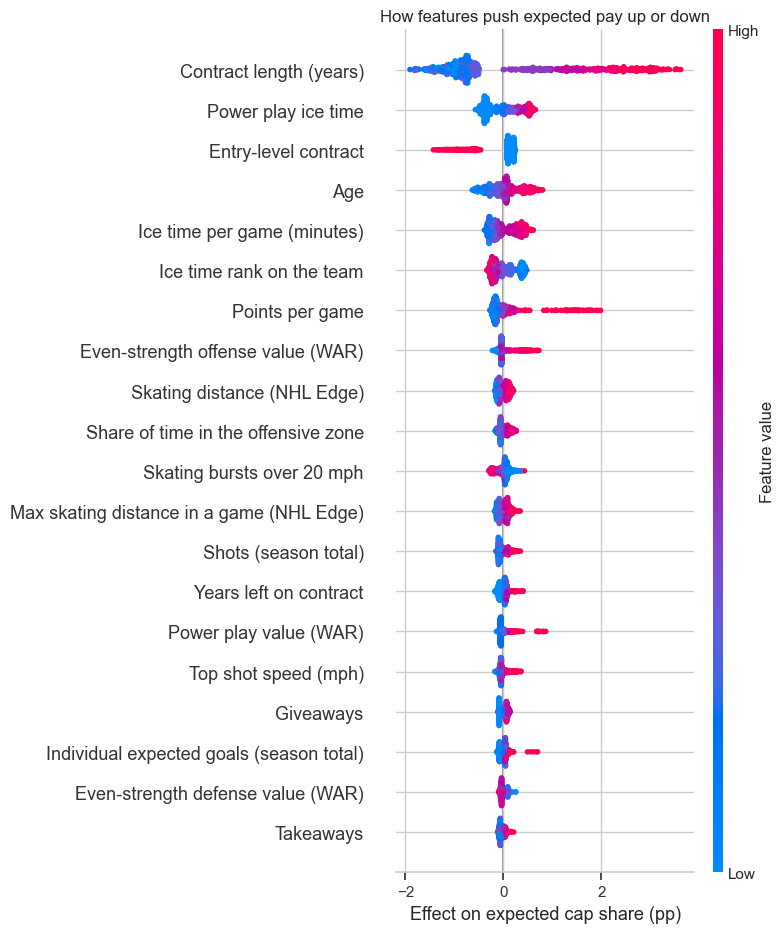

In [12]:
shap_values = model.get_feature_importance(test_pool, type="ShapValues")
shap_X = shap_values[:, :-1]

try:
    import shap

    shap.summary_plot(
        shap_X * PP,
        X_test,
        feature_names=labs(FEATURE_COLS),
        max_display=20,
        show=False,
    )
    plt.gca().set_xlabel("Effect on expected cap share (pp)")
    plt.title("How features push expected pay up or down")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Beeswarm skipped: {type(e).__name__}: {e}")


### 3b. Length vs everything else

For each 25/26 skater, SHAP is summed into two blocks (pp of cap share). Length is the price-band anchor. Everything else is the remaining adjustment.

Zone examples:
- top-right: Nathan MacKinnon (long deal + strong profile)
- top-left: Sidney Crosby (short deal + strong profile); blue **Macklin Celebrini** as an ELC example
- bottom-right: William Carrier (long deal + soft profile)
- bottom-left: Jacob Melanson (short deal + soft profile; often ELC / short structures, not only ELC)


How far each block moves expected cap share (pp)


,block,median,p95 |impact|,max up,max down
0,Contract length,-0.71,2.98,3.62,-1.91
1,Everything else,-0.50,3.38,8.34,-2.41



Largest |everything else| moves (top 10)


,Player,Team,Actual cap share (%),Expected cap share (%),Residual (pp),Length effect (pp),Everything else (pp)
1534,Nathan MacKinnon,COL,13.19,14.21,-1.01,2.240019,8.335177
1532,Connor McDavid,EDM,13.09,13.41,-0.32,2.165065,7.615023
1541,Jason Robertson,DAL,8.12,10.29,-2.17,0.021863,6.632544
1552,Artemi Panarin,LAK,12.19,11.47,0.73,1.917460,5.914729
1545,Kirill Kaprizov,MIN,9.42,10.03,-0.61,0.755285,5.645491
1544,Jack Eichel,VGK,10.47,11.43,-0.96,2.348109,5.451345
1551,Alex DeBrincat,DET,8.25,9.19,-0.94,0.120311,5.437152
1546,Jake Guentzel,TBL,9.42,10.72,-1.29,1.748539,5.333612
1533,Nikita Kucherov,TBL,9.95,11.08,-1.13,2.197373,5.246075
1554,Zach Werenski,CBJ,10.03,10.11,-0.07,1.230821,5.245364


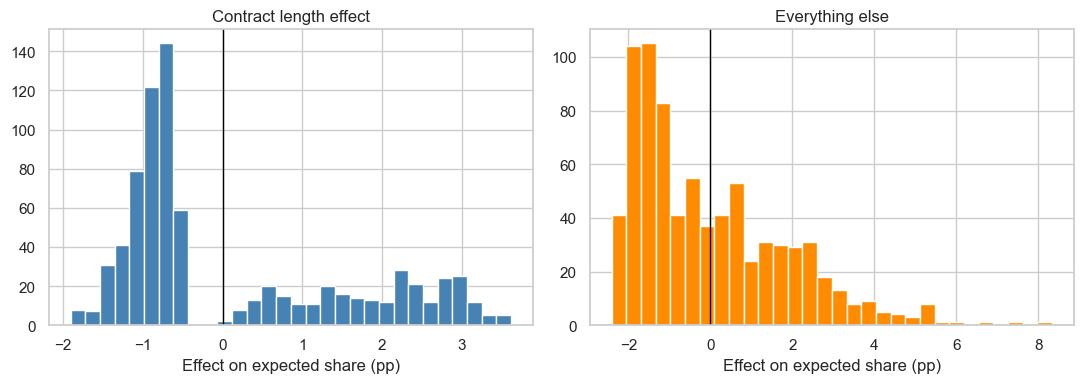

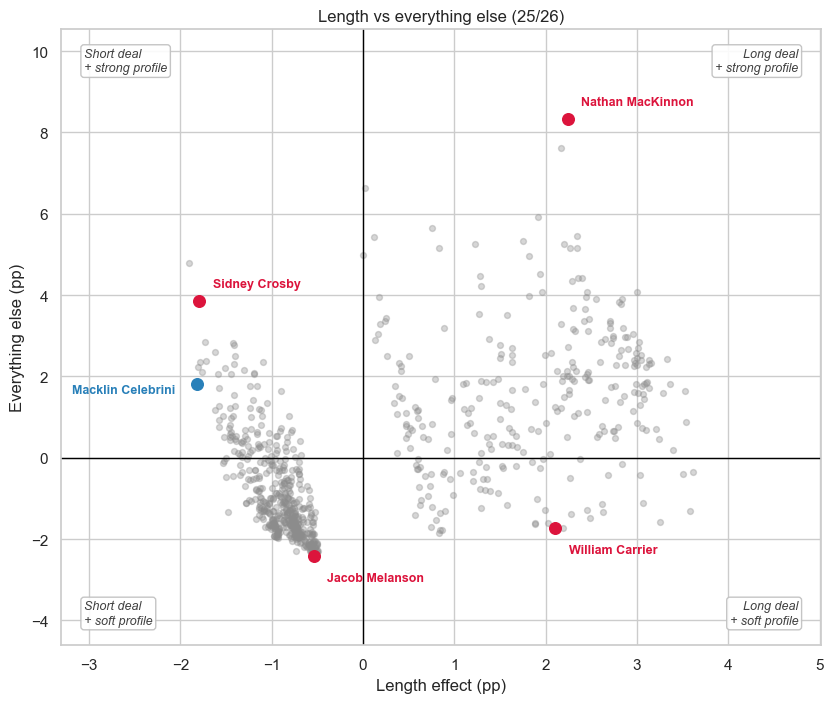

median |length| = 0.98 pp; median |everything else| = 1.46 pp; p95 |everything else| = 3.38 pp


In [14]:
FEATURE_GROUPS = {
    "length": ["ContractLength"],
    "term_other": ["YearsRemaining", "Is_ELC"],
    "performance": [
        "WAR_per_GP", "EVO WAR", "EVD WAR", "PP WAR", "PK WAR",
        "pointsPerGame", "ixG", "shots",
        "xGF%", "OZ Start%", "xG_diff",
        "Hits", "HitsT", "BkS", "TkA", "GvA", "penaltyMinutes", "DZ Start%",
        "nhl_edge_skatingSpeedMax_mph", "nhl_edge_burstsOver20", "nhl_edge_topShotSpeed_mph",
        "nhl_edge_totalDistanceSkated_mph", "nhl_edge_distanceMaxGame_mph",
        "nhl_edge_zoneTime_offensiveZonePctg",
    ],
    "role_context": [
        "Season_id", "Pos_group", "S/C", "Age", "heightInInches", "weightInPounds", "GP",
        "TOI/GP", "Depth_TOI_rank", "PP TOI", "PK TOI",
        "Team_pointPct", "Team_GF_pct", "Team_PP%", "Team_PK%",
    ],
}
assert sorted(f for cols in FEATURE_GROUPS.values() for f in cols) == sorted(FEATURE_COLS)

feat_idx = {f: i for i, f in enumerate(FEATURE_COLS)}


def group_shap_pp(cols):
    return shap_X[:, [feat_idx[c] for c in cols]].sum(axis=1) * PP


blocks = pd.DataFrame(
    {
        "length_pp": group_shap_pp(FEATURE_GROUPS["length"]),
        "rest_no_length_pp": (
            group_shap_pp(FEATURE_GROUPS["term_other"])
            + group_shap_pp(FEATURE_GROUPS["performance"])
            + group_shap_pp(FEATURE_GROUPS["role_context"])
        ),
    },
    index=test.index,
)
group_pp = review[["Player", "Team", "actual_pct", "pred_pct", "residual_pp"]].join(blocks)

summary = pd.DataFrame(
    [
        {
            "block": label,
            "median": float(group_pp[col].median()),
            "p95 |impact|": float(group_pp[col].abs().quantile(0.95)),
            "max up": float(group_pp[col].max()),
            "max down": float(group_pp[col].min()),
        }
        for col, label in [
            ("length_pp", "Contract length"),
            ("rest_no_length_pp", "Everything else"),
        ]
    ]
)
print("How far each block moves expected cap share (pp)")
display(summary.round(2))

G_COLS = ["Player", "Team", "actual_pct", "pred_pct", "residual_pp", "length_pp", "rest_no_length_pp"]
print("\nLargest |everything else| moves (top 10)")
show_players(
    group_pp.reindex(group_pp["rest_no_length_pp"].abs().sort_values(ascending=False).index).head(10),
    G_COLS,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(group_pp["length_pp"], bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="black", lw=1)
axes[0].set_title("Contract length effect")
axes[0].set_xlabel("Effect on expected share (pp)")

axes[1].hist(group_pp["rest_no_length_pp"], bins=30, color="darkorange", edgecolor="white")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("Everything else")
axes[1].set_xlabel("Effect on expected share (pp)")
plt.tight_layout()
plt.show()

ZONE_LABELS = [
    ("Nathan MacKinnon", "crimson", (10, 10)),
    ("Sidney Crosby", "crimson", (10, 10)),
    ("William Carrier", "crimson", (10, -18)),
    ("Jacob Melanson", "crimson", (10, -18)),
    ("Macklin Celebrini", "#2980b9", (-90, -6)),  # ELC example
]

fig, ax = plt.subplots(figsize=(8.5, 7.2))
ax.scatter(group_pp["length_pp"], group_pp["rest_no_length_pp"], alpha=0.35, s=18, color="0.55")
ax.axhline(0, color="black", lw=1)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Length effect (pp)")
ax.set_ylabel("Everything else (pp)")
ax.set_title("Length vs everything else (25/26)")

x_pad, y_pad = 1.4, 2.2
ax.set_xlim(group_pp["length_pp"].min() - x_pad, group_pp["length_pp"].max() + x_pad)
ax.set_ylim(group_pp["rest_no_length_pp"].min() - y_pad, group_pp["rest_no_length_pp"].max() + y_pad)

xlim, ylim = ax.get_xlim(), ax.get_ylim()
for xf, yf, ha, va, text in [
    (0.97, 0.97, "right", "top", "Long deal\n+ strong profile"),
    (0.03, 0.97, "left", "top", "Short deal\n+ strong profile"),
    (0.97, 0.03, "right", "bottom", "Long deal\n+ soft profile"),
    (0.03, 0.03, "left", "bottom", "Short deal\n+ soft profile"),
]:
    ax.text(
        xlim[0] + xf * (xlim[1] - xlim[0]),
        ylim[0] + yf * (ylim[1] - ylim[0]),
        text,
        ha=ha,
        va=va,
        fontsize=9,
        color="0.25",
        fontstyle="italic",
        zorder=3,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.75", alpha=0.9),
    )

for name, color, offset in ZONE_LABELS:
    row = group_pp.loc[group_pp["Player"] == name]
    if row.empty:
        continue
    x = float(row["length_pp"].iloc[0])
    y = float(row["rest_no_length_pp"].iloc[0])
    ax.scatter([x], [y], s=70, color=color, zorder=5)
    ax.annotate(name, (x, y), textcoords="offset points", xytext=offset, fontsize=9, fontweight="bold", color=color)

plt.tight_layout()
plt.show()

print(
    f"median |length| = {group_pp['length_pp'].abs().median():.2f} pp; "
    f"median |everything else| = {group_pp['rest_no_length_pp'].abs().median():.2f} pp; "
    f"p95 |everything else| = {group_pp['rest_no_length_pp'].abs().quantile(0.95):.2f} pp"
)


### Takeaways

Contract length sets the price band. After that anchor, performance, role, and ELC / years left still move expected share a lot: typical |everything else| is around or above typical |length|, and star tails go much higher. Length is not the whole story; it is the starting band. The expensive corner of the map is long deals with strong profiles. Soft long deals and soft short / ELC structures land elsewhere for different reasons.


## 4. Entry-level: next-contract potential

On an entry-level deal, a large under residual is not underpaid today. Pay is mostly CBA-capped. Read it as **next-contract potential**.

Tables keep actual / expected cap share and residual, plus simple raw stats. Then the same rows with expected share if the ELC flag were off, and signed next deals only where public. Rumored deals stay blank.


In [17]:
elc_review = review[review["Is_ELC"] == 1].sort_values("residual_pct")

print(f"ELC rows in 25/26: {len(elc_review)}")
print("\nELC only: most under vs model (top 15)")
show_players(elc_review.head(15), ELC_PERF_COLS)


ELC rows in 25/26: 121

ELC only: most under vs model (top 15)


,Player,Team,Age,Position,Actual cap share (%),Expected cap share (%),Residual (pp),Games played,Points per game,Ice time per game (minutes),Shots (season total)
1535,Macklin Celebrini,SJS,19,C,1.02,3.63,-2.61,82,1.40,21.31,287
1566,Connor Bedard,CHI,20,C,0.99,2.64,-1.64,69,1.09,20.85,226
1621,Matthew Schaefer,NYI,18,D,1.02,2.12,-1.10,82,0.72,24.68,222
1615,Beckett Sennecke,ANA,19,W,0.99,2.03,-1.04,82,0.73,17.45,197
1588,Leo Carlsson,ANA,20,C,0.99,1.98,-0.99,70,0.96,19.15,193
1653,Josh Doan,BUF,23,W,0.97,1.86,-0.89,82,0.63,15.87,170
1887,Louis Crevier,CHI,24,D,0.94,1.80,-0.86,78,0.32,17.14,114
1793,Alexander Nikishin,CAR,23,D,0.97,1.78,-0.82,81,0.41,18.18,122
2110,Anton Frondell,CHI,18,C,1.02,1.81,-0.79,12,0.75,17.63,36
1935,Matvei Gridin,CGY,19,W,0.99,1.75,-0.77,37,0.54,15.15,70


In [18]:
# Same stats, Is_ELC turned off (rough post-ELC expected share)
X_elc = X_test.loc[elc_review.index].copy()
X_elc_cf = X_elc.copy()
X_elc_cf["Is_ELC"] = 0

pred_elc = model.predict(X_elc)
pred_cf = model.predict(X_elc_cf)

# Signed public next deals only (AAV $M, length). Checked 2026-07-31.
NEXT_DEALS = {
    "Macklin Celebrini": (18.8, 5),
    "Leo Carlsson": (18.0, 5),
    "Connor Bedard": (15.0, 5),
    "Logan Cooley": (10.0, 8),
    "Ivan Demidov": (9.15, 8),
    "Lane Hutson": (8.85, 8),
    "Zach Benson": (7.5, 7),
    "Brandt Clarke": (7.4, 5),
    "Simon Nemec": (7.25, 5),
    "Pavel Mintyukov": (7.2, 5),
    "Josh Doan": (6.95, 7),
    "Frank Nazar": (6.59, 7),
    "Logan Stankoven": (6.0, 8),
    "William Eklund": (5.6, 3),
    "Jackson Blake": (5.12, 8),
    "Collin Graf": (4.25, 3),
    "Olen Zellweger": (3.1, 3),
    "Emil Andrae": (1.55, 2),
    "Fedor Svechkov": (1.25, 2),
    "Stephen Halliday": (1.075, 2),
    "Ivan Miroshnichenko": (0.925, 2),
}

elc_cf = elc_review.copy()
elc_cf["pred_pct_elc"] = pred_elc
elc_cf["pred_pct_if_not_ELC"] = pred_cf
elc_cf["residual_pp"] = elc_cf["actual_pct"] - elc_cf["pred_pct_elc"]
elc_cf["next_deal"] = elc_cf["Player"].map(lambda p: "Extension (public)" if p in NEXT_DEALS else "")
elc_cf["next_aav_m"] = elc_cf["Player"].map(lambda p: NEXT_DEALS.get(p, (np.nan, np.nan))[0])
elc_cf["next_length"] = elc_cf["Player"].map(lambda p: NEXT_DEALS.get(p, (np.nan, np.nan))[1])

CF_COLS = [
    "Player", "Team", "Age", "Pos_group",
    "actual_pct", "pred_pct_elc", "pred_pct_if_not_ELC", "residual_pp",
    "GP", "pointsPerGame", "TOI/GP", "shots",
    "next_deal", "next_aav_m", "next_length",
]

print("ELC counterfactual + signed next deals (top under, 15)")
show_players(elc_cf.head(15), CF_COLS)

print("\nSigned next-deal reference")
signed = elc_cf[elc_cf["next_deal"] != ""].sort_values("next_aav_m", ascending=False)
show_players(signed, CF_COLS)
print(f"\nSigned next deals matched in this ELC sample: {len(signed)}")


ELC counterfactual + signed next deals (top under, 15)


,Player,Team,Age,Position,Actual cap share (%),Expected % (as ELC),Expected % if not ELC,Residual (pp),Games played,Points per game,Ice time per game (minutes),Shots (season total),Signed next deal,Next AAV / CapHit ($M),Next length (years)
1535,Macklin Celebrini,SJS,19,C,1.02,3.63,5.53,-2.61,82,1.40,21.31,287,Extension (public),18.80,5.0
1566,Connor Bedard,CHI,20,C,0.99,2.64,4.30,-1.64,69,1.09,20.85,226,Extension (public),15.00,5.0
1621,Matthew Schaefer,NYI,18,D,1.02,2.12,3.84,-1.10,82,0.72,24.68,222,,NaN,NaN
1615,Beckett Sennecke,ANA,19,W,0.99,2.03,3.65,-1.04,82,0.73,17.45,197,,NaN,NaN
1588,Leo Carlsson,ANA,20,C,0.99,1.98,3.75,-0.99,70,0.96,19.15,193,Extension (public),18.00,5.0
1653,Josh Doan,BUF,23,W,0.97,1.86,3.23,-0.89,82,0.63,15.87,170,Extension (public),6.95,7.0
1887,Louis Crevier,CHI,24,D,0.94,1.80,2.50,-0.86,78,0.32,17.14,114,,NaN,NaN
1793,Alexander Nikishin,CAR,23,D,0.97,1.78,2.95,-0.82,81,0.41,18.18,122,,NaN,NaN
2110,Anton Frondell,CHI,18,C,1.02,1.81,3.18,-0.79,12,0.75,17.63,36,,NaN,NaN
1935,Matvei Gridin,CGY,19,W,0.99,1.75,2.89,-0.77,37,0.54,15.15,70,,NaN,NaN



Signed next-deal reference


,Player,Team,Age,Position,Actual cap share (%),Expected % (as ELC),Expected % if not ELC,Residual (pp),Games played,Points per game,Ice time per game (minutes),Shots (season total),Signed next deal,Next AAV / CapHit ($M),Next length (years)
1535,Macklin Celebrini,SJS,19,C,1.02,3.63,5.53,-2.61,82,1.40,21.31,287,Extension (public),18.800,5.0
1588,Leo Carlsson,ANA,20,C,0.99,1.98,3.75,-0.99,70,0.96,19.15,193,Extension (public),18.000,5.0
1566,Connor Bedard,CHI,20,C,0.99,2.64,4.30,-1.64,69,1.09,20.85,226,Extension (public),15.000,5.0
1703,Logan Cooley,UTA,21,C,0.99,1.10,2.56,-0.10,54,0.80,17.33,102,Extension (public),10.000,8.0
1607,Ivan Demidov,MTL,19,W,0.99,1.34,2.78,-0.36,82,0.76,15.50,127,Extension (public),9.150,8.0
1561,Lane Hutson,MTL,21,D,0.99,1.66,3.42,-0.66,82,0.95,23.77,124,Extension (public),8.850,8.0
1704,Zach Benson,BUF,20,W,0.99,1.25,2.65,-0.25,65,0.66,15.89,116,Extension (public),7.500,7.0
1728,Brandt Clarke,LAK,22,D,0.90,1.23,2.76,-0.32,82,0.49,19.80,159,Extension (public),7.400,5.0
1867,Simon Nemec,NJD,21,D,0.96,1.62,3.01,-0.66,68,0.38,19.67,101,Extension (public),7.250,5.0
1915,Pavel Mintyukov,ANA,21,D,0.96,1.23,2.48,-0.27,73,0.30,18.43,79,Extension (public),7.200,5.0



Signed next deals matched in this ELC sample: 21


### Takeaways

For entry-level names, prefer next-contract potential over underpaid today. Many strong ELC under signals already signed next deals, from record AAVs (Celebrini, Carlsson, Bedard) down to bridges. Public extensions in this sample (for example Demidov 8x about $9.15M, or shorter bridges) help validate the lens: the model is pointing at upside before the next contract prints. Unsigned names stay blank on purpose.


## 5. Summary

Short conclusions you can reuse in a README, deck, or interview. Numbers refer to **this sample** (GP ≥ 10 lean table; holdout `25/26`).

1. **Idea.** Cap hit is a fact. Value is a judgment call. The gap between actual and expected share is a starting point for talks and comps, not a final roster or market decision.
2. **Model quality.** Holdout miss averages about **$0.77M**; roughly **seven in ten** skaters land inside about **$1M** of expected pay; **R² ~0.86**. Stable enough to rank second looks.
3. **League signal.** Residuals can be large. Outliers prove the tool finds atypical contracts, not only the middle of the market.
4. **Drivers.** **Contract length** anchors the price band. Performance, role, team context, and ELC / years left still move expected share inside that band.
5. **Zones.** Long + strong profiles sit in the expensive corner. Short + strong can still look valuable on the map. Long + soft is length carrying expected pay. Short + soft is often ELC or short-term structure with a softer profile, not ELC only.
6. **Entry-level.** Large ELC under residuals are a **next-deal pipeline** lens. Use the if-not-ELC counterfactual and the signed-deal reference table. Do not say the model predicted a specific AAV before the deal signed; say the public deal lines up with the upside the residual was flagging.
7. **Limits.** Same-season stats describe expected pay given that season profile; many deals were signed earlier. Goalies are out of this skater model. Residual is not a club-mistake fact.
8. **How to use it.** Sort by residual, read length and ELC context, then open local SHAP / group SHAP for the names that matter for comps or negotiation prep.
